In [ ]:
#Q:21
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X,y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
base_estimator = DecisionTreeClassifier(random_state=42)
bagging_clf = BaggingClassifier(estimator=base_estimator,n_estimators=100,random_state=42)
bagging_clf.fit(x_train,y_train)
y_pred= bagging_clf.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))

#Q:22
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import mean_squared_error

X,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
base_estimator = DecisionTreeClassifier(random_state=42)
bagging_clf = BaggingClassifier(estimator=base_estimator,n_estimators=100,random_state=42)
bagging_clf.fit(x_train,y_train)
y_pred = bagging_clf.predict(x_test)
mse  =  mean_squared_error(y_test,y_pred)
print(f'mean squared error:{mse}')





accuracy: 0.88
mean squared error:0.12


In [ ]:
#Q:23
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

data = load_breast_cancer()
x = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

rfc_clf = RandomForestClassifier(n_estimators=100,random_state=42)
rfc_clf.fit(x,y)

importances = rfc_clf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature':data.feature_names,
    'Importance':importances
})
feature_importance = feature_importance_df.sort_values(by='Importance',ascending=False)
print(feature_importance.to_string(index=False))



                Feature  Importance
             worst area    0.139357
   worst concave points    0.132225
    mean concave points    0.107046
           worst radius    0.082848
        worst perimeter    0.080850
         mean perimeter    0.067990
         mean concavity    0.066917
              mean area    0.060462
        worst concavity    0.037339
            mean radius    0.034843
             area error    0.029553
      worst compactness    0.019864
          worst texture    0.017485
           mean texture    0.015225
           radius error    0.014264
       worst smoothness    0.012232
       mean compactness    0.011597
        perimeter error    0.010085
         worst symmetry    0.008179
        mean smoothness    0.007958
fractal dimension error    0.005942
        concavity error    0.005820
      compactness error    0.005612
       smoothness error    0.004722
worst fractal dimension    0.004497
   concave points error    0.003760
          texture error    0

In [ ]:
#Q:24
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

RFC = RandomForestClassifier(n_estimators=100,random_state=42)
RFC.fit(x_train,y_train)
y_pred_rf = RFC.predict(x_test)
accuracy_rfc = accuracy_score(y_test,y_pred_rf)

DTC = DecisionTreeClassifier(random_state=42)
DTC.fit(x_train,y_train)
y_pred_dtc = DTC.predict(x_test)
accuracy_dtc = accuracy_score(y_test,y_pred_dtc)

print("performance of RandomForestClasifier:",accuracy_rfc)
print("performance of single decision tree:",accuracy_dtc)


performance of RandomForestClasifier: 0.9707602339181286
performance of single decision tree: 0.9415204678362573


In [ ]:
#Q:25
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

X,y = load_breast_cancer(return_X_y=True)
model = RandomForestClassifier(n_estimators=100,oob_score=True,random_state=42)
model.fit(X,y)

oob_score = model.oob_score_
print(f"OOB Score:{oob_score}")

OOB Score:0.961335676625659


In [16]:
#Q:26
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

x,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
base_model = SVC(kernel='rbf')
bagging_clf = BaggingClassifier(estimator=base_model,n_estimators=100,random_state=42)
bagging_clf.fit(x_train,y_train)
y_pred = bagging_clf.predict(x_test)
print("accuracy score:",accuracy_score(y_test,y_pred))


accuracy score: 0.9333333333333333


In [ ]:
#Q:27
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

x,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=42)
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

tree_counts = [1,5,10,50,100,200,500]
result = []

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n,random_state=42)
    rf.fit(x_train,y_train)
    y_pred = rf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)

    result.append({'Numbers of trees':n,'Accuracy':accuracy})

    df_result = pd.DataFrame(result)
    print(df_result.to_string(index=False))


 Numbers of trees  Accuracy
                1      0.73
 Numbers of trees  Accuracy
                1      0.73
                5      0.85
 Numbers of trees  Accuracy
                1     0.730
                5     0.850
               10     0.875
 Numbers of trees  Accuracy
                1     0.730
                5     0.850
               10     0.875
               50     0.900
 Numbers of trees  Accuracy
                1     0.730
                5     0.850
               10     0.875
               50     0.900
              100     0.900
 Numbers of trees  Accuracy
                1     0.730
                5     0.850
               10     0.875
               50     0.900
              100     0.900
              200     0.880
 Numbers of trees  Accuracy
                1     0.730
                5     0.850
               10     0.875
               50     0.900
              100     0.900
              200     0.880
              500     0.885


In [ ]:
#Q:28
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score

x,y = make_classification(n_samples=1000,
                          n_features=20,
                          n_informative=15,
                          n_redundant=5,
                          random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
base_model = LogisticRegression()
bagging_clf = BaggingClassifier(estimator=base_model,n_estimators=100,random_state=42)
bagging_clf.fit(x_train,y_train)
y_proba = bagging_clf.predict_proba(x_test)[:,1]
auc_score = roc_auc_score(y_test,y_proba)
print("auc_score:",auc_score)


In [27]:
#Q:29
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

data = load_breast_cancer()
x = pd.DataFrame(data.data , columns=data.feature_names)
y = data.target
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(x,y)
feature_importance = rfc.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': feature_importance
})

importance = feature_importance_df.sort_values(by='Importance',ascending=False)
print(importance.to_string(index=False))



                Feature  Importance
             worst area    0.139357
   worst concave points    0.132225
    mean concave points    0.107046
           worst radius    0.082848
        worst perimeter    0.080850
         mean perimeter    0.067990
         mean concavity    0.066917
              mean area    0.060462
        worst concavity    0.037339
            mean radius    0.034843
             area error    0.029553
      worst compactness    0.019864
          worst texture    0.017485
           mean texture    0.015225
           radius error    0.014264
       worst smoothness    0.012232
       mean compactness    0.011597
        perimeter error    0.010085
         worst symmetry    0.008179
        mean smoothness    0.007958
fractal dimension error    0.005942
        concavity error    0.005820
      compactness error    0.005612
       smoothness error    0.004722
worst fractal dimension    0.004497
   concave points error    0.003760
          texture error    0

In [ ]:
#Q:30
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC

x,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
base_model = SVC(kernel='rbf')
bagging_clf = BaggingClassifier(estimator=base_model,n_estimators=100,random_state=42)

rfc.fit(x_train,y_train)
bagging_clf.fit(x_train,y_train)

y_pred_rfc = rfc.predict(x_test)
y_pred_bag = bagging_clf.predict(x_test)

print("accuracy of random forest model:",accuracy_score(y_test,y_pred_rfc))
print("accuracy of bagging model:",accuracy_score(y_test,y_pred_bag))


accuracy of random forest model: 0.9649122807017544
accuracy of bagging model: 0.9473684210526315


In [2]:
#Q:31
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report

x,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rfc= RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[None,10,20],
    'min_samples_split':[2,4,5],
    'criterion':['gini','entrophy']
}

grid_search = GridSearchCV(estimator=rfc,param_grid=param_grid,cv=5,verbose=1,scoring='accuracy')

grid_search.fit(x_train,y_train)
print("\n---grid search optimization Results---")
print(f"best param:{grid_search.best_params_}")
print(f"best cross validation accuracy:{grid_search.best_score_}")
y_pred = grid_search.predict(x_test)
print(f'final model test{classification_report(y_test,y_pred)}')



Fitting 5 folds for each of 54 candidates, totalling 270 fits


C:\Users\THIS_P\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
135 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
135 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\THIS_P\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\THIS_P\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\THIS_P\AppData\Roaming\


---grid search optimization Results---
best param:{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
best cross validation accuracy:0.9626373626373625
final model test              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
#Q:32
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,r2_score

x,y = load_digits(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
base_estimator = SVR()
estimator_list = [5,10,25,50,100,200]
results = []

for n in estimator_list:
    bagg = BaggingRegressor(estimator=base_estimator,n_estimators=n,random_state=42)
    bagg.fit(x_train,y_train)
    y_pred = bagg.predict(x_test)

    mse = mean_squared_error(y_test,y_pred)
    r2_Score = r2_score(y_test,y_pred)

    results.append({'n_estimators':n,
                    'MSE':round(mse,4),
                    'r2_score':round(r2_Score,4)})
    #Display result
    df_result = pd.DataFrame(results)
    print(df_result.to_string(index=False))


 n_estimators    MSE  r2_score
            5 1.0981    0.8578
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
          100 1.1106    0.8562
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
          100 1.1106    0.8562
          200 1.1116    0.8561


In [7]:
#Q:33
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

x,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(x_train,y_train)
y_pred = rfc.predict(x_test)
y_probs = rfc.predict_proba(x_test)

misclassification_mask = (y_test != y_pred)
misclasification_indices = np.where(misclassification_mask)[0]

print(f'accuracy{accuracy_score(y_test,y_pred)}')
print(f"\n total misclasification samples:{len(misclasification_indices)} out of {len(y_test)}\n")


accuracy0.9

 total misclasification samples:20 out of 200



In [ ]:
#Q:34
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

x,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model1 = DecisionTreeClassifier(random_state=42)
model1.fit(x_train,y_train)
y_pred_single = model1.predict(x_test)

base_model = DecisionTreeClassifier()
bagging_clf = BaggingClassifier(estimator=base_model,n_estimators=100,random_state=42)
bagging_clf.fit(x_train,y_train)
y_pred_bagg = bagging_clf.predict(x_test)

print(f"accuracy of single decision tree:{accuracy_score(y_test,y_pred_single)}")
print(f"accuracy of bagging classifier:{accuracy_score(y_test,y_pred_bagg)}")

accuracy of single decision tree:0.9473684210526315
accuracy of bagging classifier:0.956140350877193


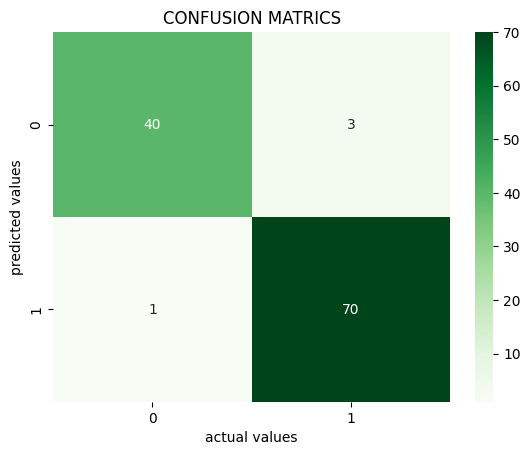

In [11]:
#Q:35
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

x,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)
y_pred = rfc.predict(x_test)
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.xlabel("actual values")
plt.ylabel("predicted values")
plt.title("CONFUSION MATRICS")
plt.show()

In [ ]:
#Q:36
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

x,y = make_classification(n_samples=1000,n_features=20,n_informative=15,n_redundant=5,random_state=42)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

dtc = DecisionTreeClassifier(max_depth=5,random_state=42)
svm = SVC(probability=True,random_state=42)
log_model = LogisticRegression()

base_estimators = [
    ('decision_tree', dtc),
    ('svm',svm),
    ('logistic_regression',log_model)
]

Stacking_clf = StackingClassifier(estimators=base_estimators,
                                  final_estimator=LogisticRegression(random_state=42),
                                  cv=5,n_jobs=-1,)

model_dict = {
    'Standalone Decision Tree':dtc,
    'Standalone SVM':svm,
    'Standalone Logistic Regression': log_model,
    'Stacked Ensemble Classifier':Stacking_clf
}

print("--Model Accuracy Comparision---")
result=[]

for name,model in model_dict.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)
    result.append({'Model Name':name,'Test Accuracy':accuracy})
    df_results = pd.DataFrame(result)
    print(df_result.to_string(index=False))


--Model Accuracy Comparision---
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
          100 1.1106    0.8562
          200 1.1116    0.8561
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
          100 1.1106    0.8562
          200 1.1116    0.8561
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
          100 1.1106    0.8562
          200 1.1116    0.8561
 n_estimators    MSE  r2_score
            5 1.0981    0.8578
           10 1.1129    0.8559
           25 1.1064    0.8568
           50 1.1089    0.8564
          100 1.1106    0.8562
          200 1.1116    0.8561


In [16]:
#Q:37
from sklearn.datasets import load_breast_cancer

from sklearn.ensemble import RandomForestClassifier
data1 = load_breast_cancer()
x = pd.DataFrame(data1.data,columns=data1.feature_names)
y = data1.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(x,y)
importance = rfc.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature_name':x.columns,
    'Importance_score':importance
})
top_5_features = feature_importance_df.sort_values(by='Importance_score',ascending=False).head(5)

print(top_5_features)


            Feature_name  Importance_score
23            worst area          0.139357
27  worst concave points          0.132225
7    mean concave points          0.107046
20          worst radius          0.082848
22       worst perimeter          0.080850


In [21]:
#Q:38
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import precision_score,recall_score,f1_score
x,y = load_breast_cancer(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
base_model = SVC(kernel="rbf")
model = BaggingClassifier(estimator=base_model,n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("precision score:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))

precision score: 0.922077922077922
recall: 1.0
f1 score: 0.9594594594594594


In [ ]:
#Q:39
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

depth = [2,4,5,6,8,10]
for d in depth:
    model = RandomForestClassifier(max_depth=d,random_state=42)
    model.fit(x_train,y_train)
    model.predict(x_test)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test,y_pred)
    print(f"max depth:{d}, accuracy{accuracy}")


max depth:2, accuracy0.9649122807017544
max depth:4, accuracy0.9649122807017544
max depth:5, accuracy0.9649122807017544
max depth:6, accuracy0.9649122807017544
max depth:8, accuracy0.9649122807017544
max depth:10, accuracy0.9649122807017544


In [27]:
#Q:40
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

data = fetch_california_housing(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model1=DecisionTreeRegressor(random_state=42)
model2=KNeighborsRegressor()
base_estimators = {"decision tree":model1, "KNR":model2}
for i in base_estimators:
    model = BaggingRegressor(estimator=base_estimators[i],n_estimators=100,random_state=42)
    model.fit(x_train,y_train)
    model.predict(x_test)
    score = r2_score(y_test,y_pred)

    print(f'model name:{i}    r2_score:{score}')


model name:decision tree    r2_score:0.8506387160170324
model name:KNR    r2_score:0.8506387160170324


In [33]:
#Q:41
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

data = load_breast_cancer()
x = data.data
y = data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(x_train,y_train)
y_pred = rfc.predict_proba(x_test)[:,1]
print("ROC-AUC Score:",roc_auc_score(y_test,y_pred))

ROC-AUC Score: 0.9952505732066819


In [36]:
#Q:42
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


x,y = load_breast_cancer(return_X_y=True)

model = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)

scores = cross_val_score(model,x,y,cv=5)
print("Cross Validation Score:", scores)
print("Average Accuracy:",scores.mean())

Cross Validation Score: [0.89473684 0.93859649 0.99122807 0.96491228 1.        ]
Average Accuracy: 0.9578947368421054


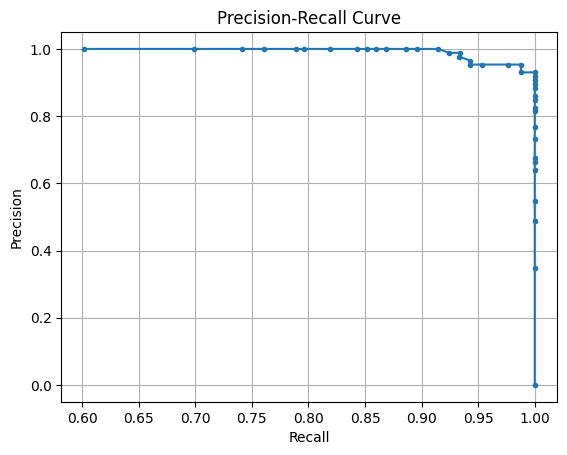

In [ ]:
#Q:43
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

x_train,x_test,y_train,y_test = train_test_split(x,y,)
model= RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict_proba(x_test)[:,1]
precision,recall,threshold = precision_recall_curve(y_test,y_pred)

plt.plot(precision,recall,marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()


In [42]:
#Q:44
from sklearn.datasets import load_iris 
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x,y = load_iris(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
rf = RandomForestClassifier(n_estimators=100,random_state=42)

stack_clf= StackingClassifier(estimators=[('rf',rf)],final_estimator=LogisticRegression())
stack_clf.fit(x_train,y_train)
y_pred = stack_clf.predict(x_test)
accu = accuracy_score(y_test,y_pred)
print("Stacking classifier Accuracy:",accu)

Stacking classifier Accuracy: 1.0


In [ ]:
#Q:45
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score

x,y = fetch_california_housing(return_X_y=True)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
samples = [0.5,0.7,1.0]

for s in samples:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=100,
        max_samples=s,
        random_state=42
    )

    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    score=r2_score(y_test,y_pred)
    print("'Boostsrap Sample:",s, "R2 Score:",score)


'Boostsrap Sample: 0.5 R2 Score: 0.7984588977292457
'Boostsrap Sample: 0.7 R2 Score: 0.8023574490650527
'Boostsrap Sample: 1.0 R2 Score: 0.8046988456668309
